# Prabal Ghosh
## OMICS PROJECT

# on ORIGINAL DATASET

# using builtin model from python

This notebook demonstrates how temporal (or spatial) covariates can be used for multimodal data integration to learn smooth latent factors using a developmental gene expression atlas comprising multiple species and organs.

In [1]:
import numpy as np
import pandas as pd
from mofapy2.run.entry_point import entry_point
import mofax
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:


# Initialize the MEFISTO model
ent = entry_point()

datadir = "C:/Users/praba/Documents/GitHub/UCA-M2-SEMESTER2/omics/MEFISTO/13233860"

data = pd.read_csv(f"{datadir}/evodevo.csv", sep=",", index_col=0)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        


In [3]:
data

,group,view,sample,feature,value,time
1,Human,Brain,10wpc_Human,ENSG00000000457_Brain,8.573918,7
2,Human,Brain,10wpc_Human,ENSG00000001084_Brain,8.875957,7
3,Human,Brain,10wpc_Human,ENSG00000001167_Brain,11.265237,7
4,Human,Brain,10wpc_Human,ENSG00000001461_Brain,7.374965,7
5,Human,Brain,10wpc_Human,ENSG00000001561_Brain,7.311018,7
...,...,...,...,...,...,...
3193836,Human,Testis,youngMidAge_Human,ENSG00000271503_Testis,1.178014,21
3193837,Human,Testis,youngMidAge_Human,ENSG00000271601_Testis,1.178014,21
3193838,Human,Testis,youngMidAge_Human,ENSG00000272442_Testis,4.476201,21
3193839,Human,Testis,youngMidAge_Human,ENSG00000272886_Testis,1.178014,21


In [4]:

# Set data options and load into MEFISTO
ent.set_data_options()
ent.set_data_df(data)

# Define model options
ent.set_model_options(factors=5)
ent.set_train_options()






Loaded group='Human' view='Brain' with N=23 samples and D=7696 features...
Loaded group='Human' view='Cerebellum' with N=23 samples and D=7696 features...
Loaded group='Human' view='Heart' with N=23 samples and D=7696 features...
Loaded group='Human' view='Liver' with N=23 samples and D=7696 features...
Loaded group='Human' view='Testis' with N=23 samples and D=7696 features...
Loaded group='Mouse' view='Brain' with N=14 samples and D=7696 features...
Loaded group='Mouse' view='Cerebellum' with N=14 samples and D=7696 features...
Loaded group='Mouse' view='Heart' with N=14 samples and D=7696 features...
Loaded group='Mouse' view='Liver' with N=14 samples and D=7696 features...
Loaded group='Mouse' view='Testis' with N=14 samples and D=7696 features...
Loaded group='Opossum' view='Brain' with N=15 samples and D=7696 features...
Loaded group='Opossum' view='Cerebellum' with N=15 samples and D=7696 features...
Loaded group='Opossum' view='Heart' with N=15 samples and D=7696 features...


In [5]:
# Set covariates (e.g., time) for temporal analysis
times = [
    data[['sample', 'time', 'group']]
    .drop_duplicates()
    .set_index('sample')
    .loc[np.concatenate(ent.data_opts['samples_names'])]
    .query('group == @g').time.values.reshape(-1, 1) 
    for g in ent.data_opts['groups_names']
]

idx = ent.data_opts['groups_names'].index("Mouse")
ent.set_covariates(times, covariates_names="time")
ent.set_smooth_options(warping=True, warping_ref=idx, model_groups=True)

Loaded 1 covariate(s) for each sample...


##
## Warping set to True: aligning the covariates across groups
##


In [6]:


# Build and run the model
ent.build()
ent.run()

# Save trained model
ent.save("evodevo_model_1.hdf5")



######################################
## Training the model with seed 434295 ##
######################################


ELBO before training: -15640466.43 

Iteration 1: time=0.76, ELBO=-3990165.36, deltaELBO=11650301.068 (74.48819460%), Factors=5
Iteration 2: time=0.73, ELBO=-3374830.98, deltaELBO=615334.384 (3.93424574%), Factors=5
Iteration 3: time=0.62, ELBO=-3251851.16, deltaELBO=122979.812 (0.78629248%), Factors=5
Iteration 4: time=0.61, ELBO=-3199105.78, deltaELBO=52745.385 (0.33723665%), Factors=5
Iteration 5: time=0.60, ELBO=-3165664.98, deltaELBO=33440.801 (0.21380949%), Factors=5
Iteration 6: time=0.91, ELBO=-3141328.15, deltaELBO=24336.832 (0.15560170%), Factors=5
Iteration 7: time=0.68, ELBO=-3123042.84, deltaELBO=18285.304 (0.11691022%), Factors=5
Iteration 8: time=0.68, ELBO=-3109604.58, deltaELBO=13438.258 (0.08591980%), Factors=5
Iteration 9: time=0.60, ELBO=-3100183.86, deltaELBO=9420.724 (0.06023301%), Factors=5
Iteration 10: time=0.65, ELBO=-3093869.89, deltaELB

In [7]:
m = mofax.mofa_model(r"C:\Users\praba\Documents\GitHub\UCA-M2-SEMESTER2\omics\MEFISTO\evodevo_model_1.hdf5")

Variance explained
First, we can take a look at the variance explained by each of the inferred factors per organ and species.

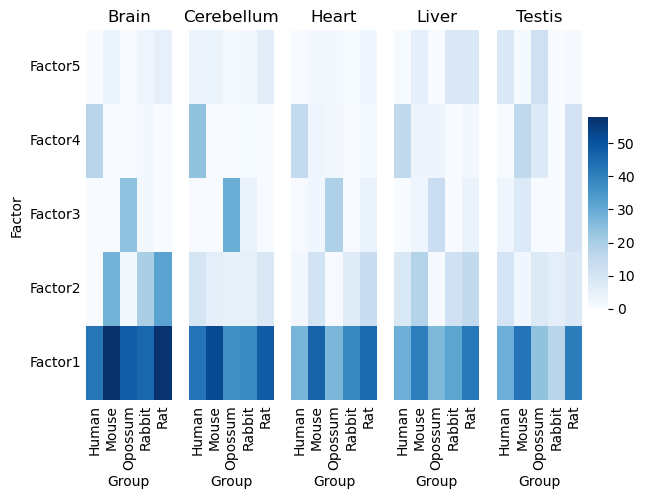

In [8]:

# Plot variance explained
mofax.plot_r2(m, cmap="Blues")



<Axes: title={'center': 'time_transformed'}, xlabel='Factor1', ylabel='Factor2'>

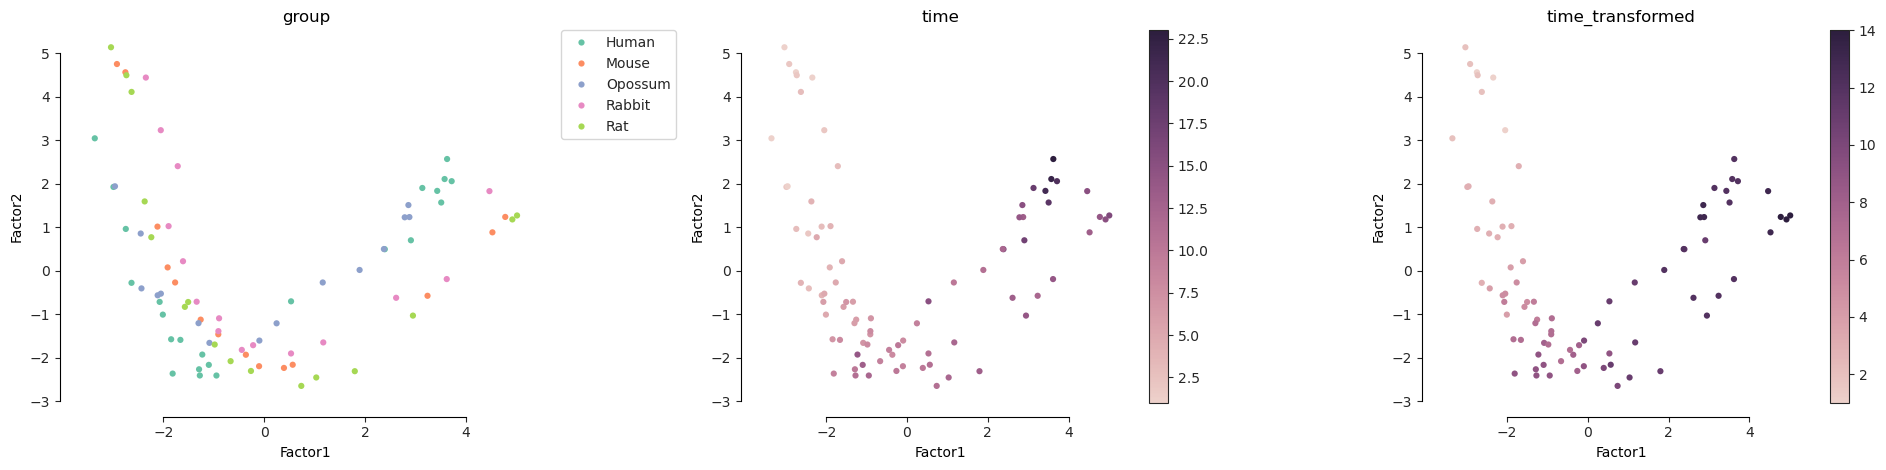

In [9]:
# Visualize factor space
mofax.plot_factors_scatter(m, x=0, y=1, color=["group", "time", "time_transformed"])



Latent factors versus common developmental time
We can plot the latent processes along the inferred common developmental time.

Before alignment:

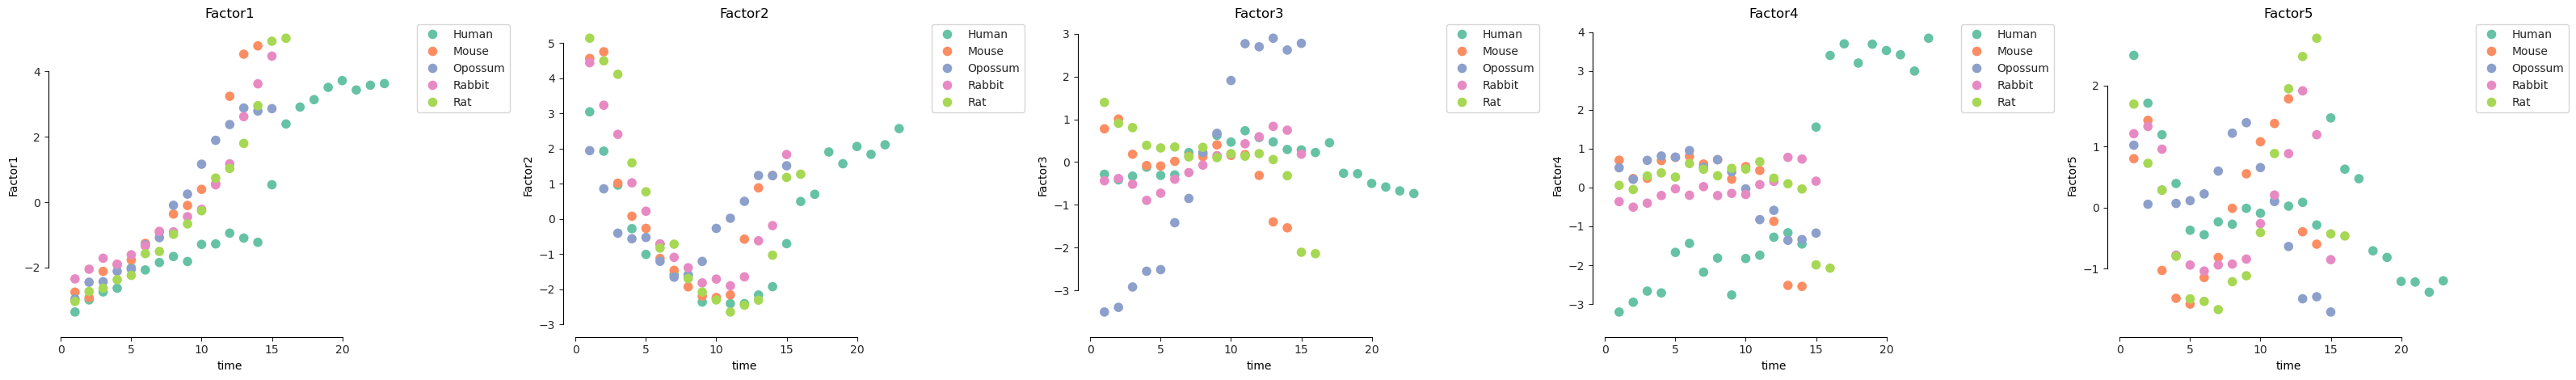

In [27]:
mofax.plot_factors_scatter(m, x="time", y=range(m.nfactors), 
                           ncols=5, size=70);

After alignment:



<Axes: title={'center': 'Factor5'}, xlabel='time_transformed', ylabel='Factor5'>

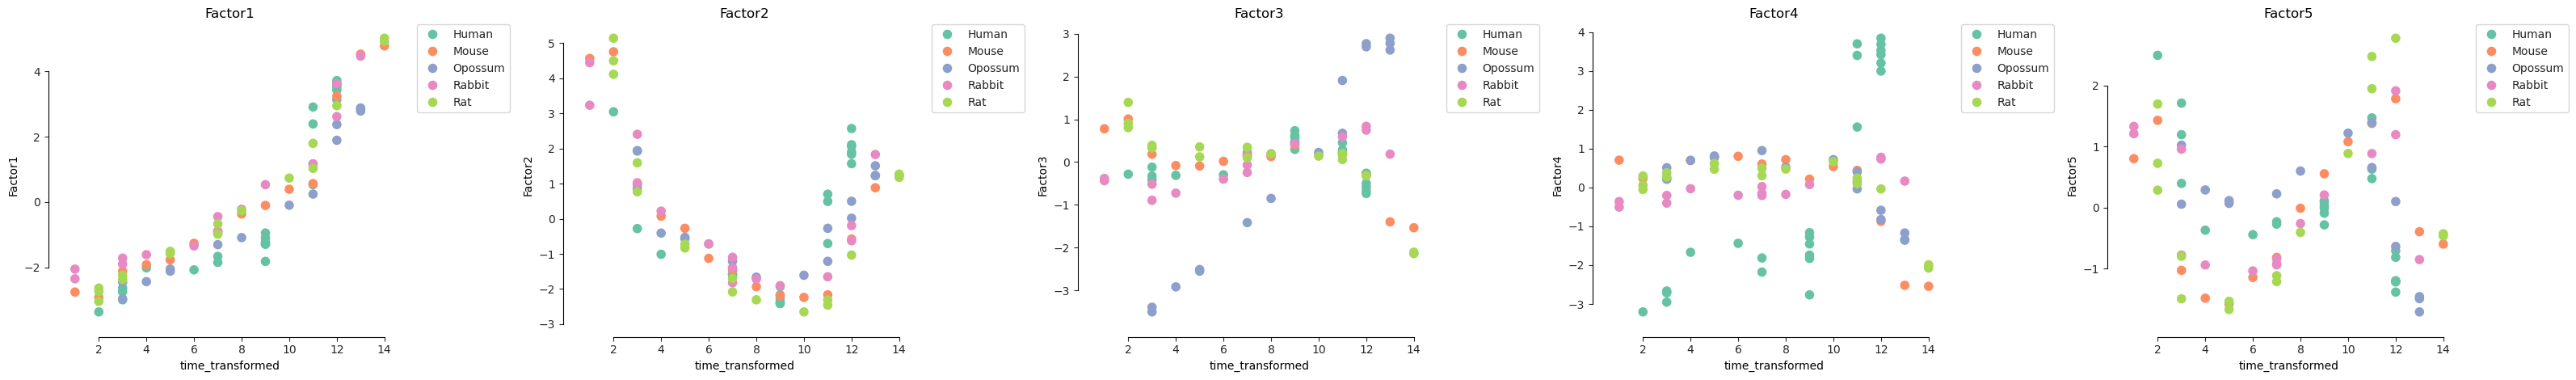

In [10]:
# Plot latent factors over developmental time
mofax.plot_factors_scatter(m, x="time_transformed", y=range(m.nfactors), ncols=5, size=70)



The scale parameters of the Gaussian process capture the smoothness of the model.
visualize them with bar plots where more colour means more smoothness:



<Axes: xlabel='Smoothness', ylabel='Factor'>

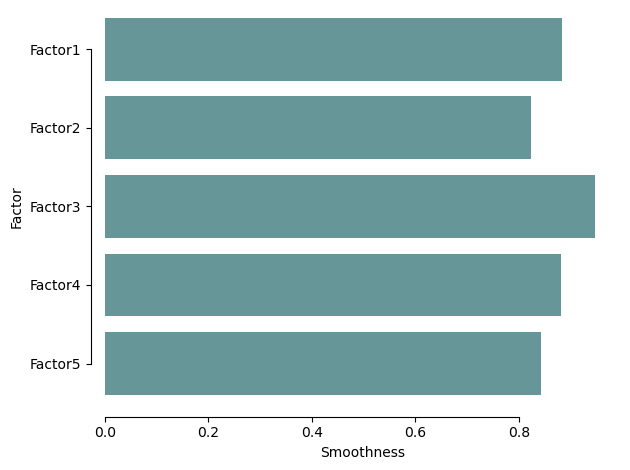

In [11]:
# Plot smoothness of factors
mofax.plot_smoothness(m)



<Axes: title={'center': 'Factor5'}, xlabel='Group', ylabel='Group'>

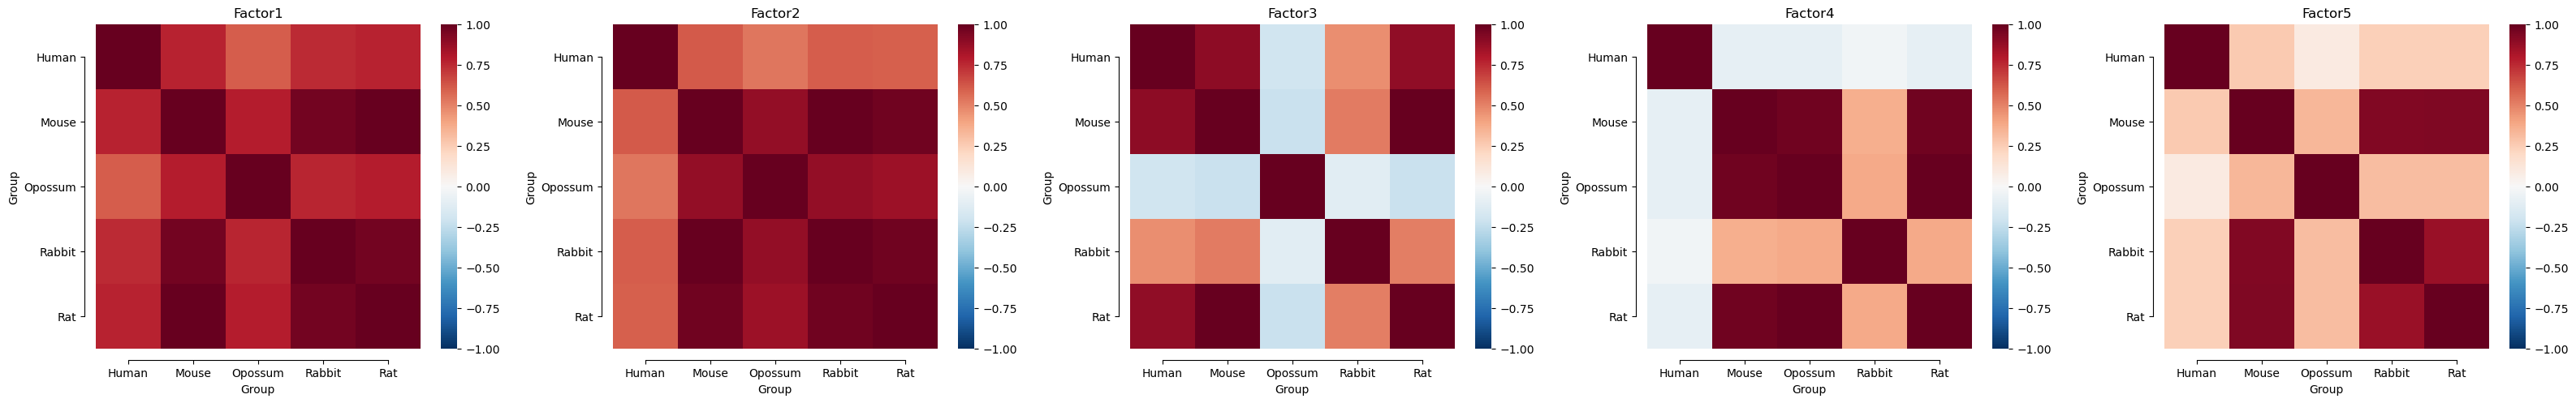

In [15]:
mofax.plot_group_kernel(m, ncols=5)


plot sharedness as a feature for each factor (fully coloured bar means fully shared):



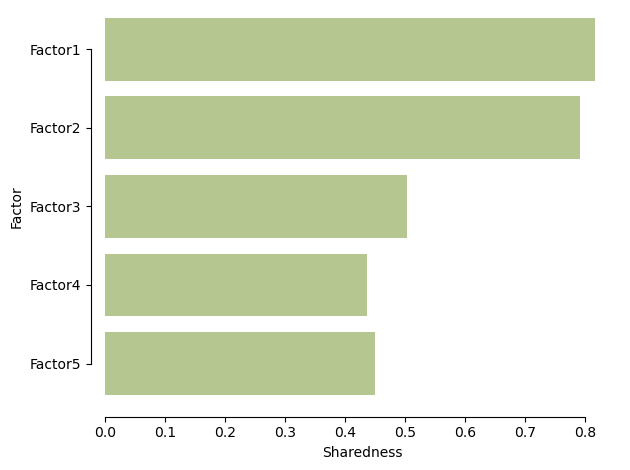

In [22]:
mofax.plot_sharedness(m);


Weights
To gain insights into the molecular signatures underlying each factor, we can investigate the weights of each factor.

<Axes: title={'center': 'Brain'}, xlabel='factor', ylabel='feature'>

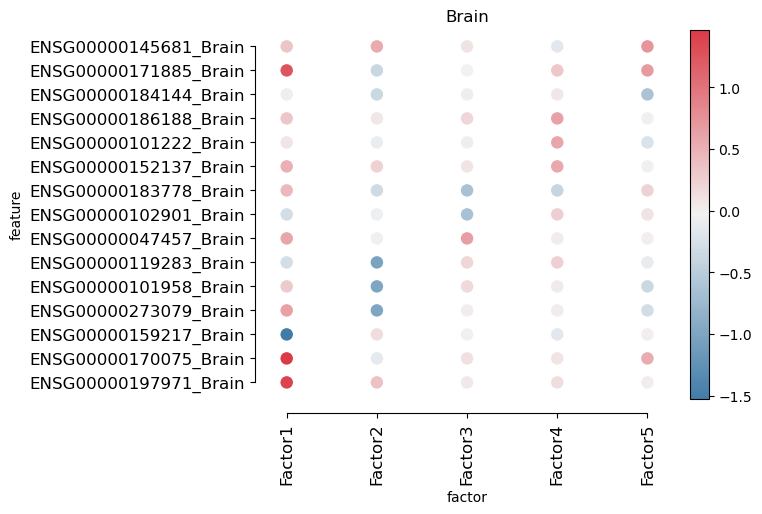

In [28]:
mofax.plot_weights_dotplot(m, view="Brain", n_features=3, 
                           yticklabels_size=12, xticklabels_size=12, size=100)


<Axes: title={'center': 'Testis'}, xlabel='factor', ylabel='feature'>

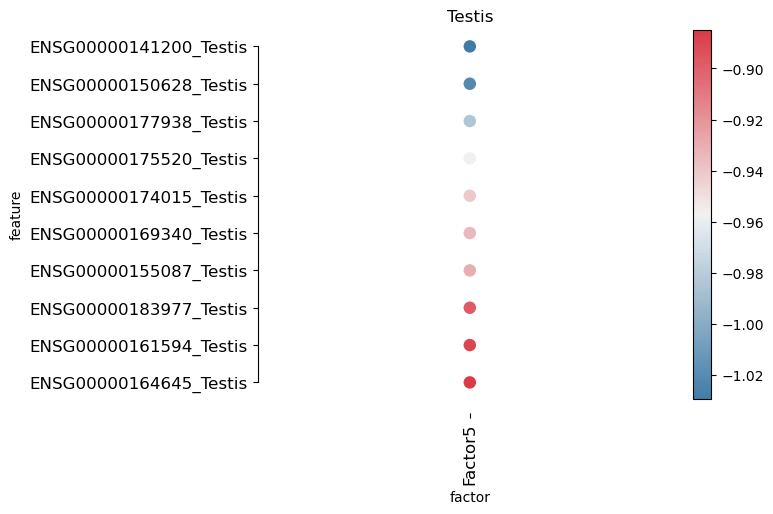

In [29]:
mofax.plot_weights_dotplot(m, view="Testis", n_features=10, factors=4,
                           yticklabels_size=12, xticklabels_size=12, size=100)
